In [1]:
import os
os.chdir('c:\\Users\\Mikael Huff\\Documents\\Training')
os.getcwd()

'c:\\Users\\Mikael Huff\\Documents\\Training'

In [5]:
import numpy as np
class Solution:
    def trapRainWater(self, heightMap: list[list[int]]) -> int:
        height_np = np.array(heightMap)
        n,m = height_np
        max_map = np.copy(height_np)
        max_map[1:n-1,1:m-1] = np.ones(height_np.shape-1) * height_np.max()
        depth = 0
        while True:
            for i in range(1,n-1):
                for j in range(1,m-1):
                    pass
            break

        

# Computer Vision

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

(3072, 3072, 3)


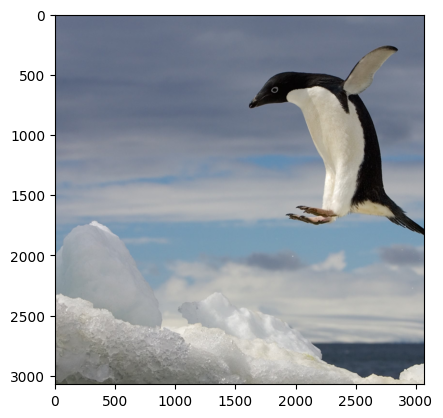

In [12]:
I = plt.imread('data/adelie-penguin.jpg')
print(I.shape)
plt.imshow(I)

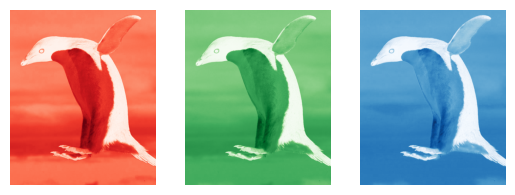

In [26]:
plt.subplot(1,3,1)
plt.axis('off')
plt.imshow(I[200:2000, 1500:3000,0], cmap='Reds')
plt.subplot(1,3,2)
plt.axis('off')
plt.imshow(I[200:2000, 1500:3000,1], cmap='Greens')
plt.subplot(1,3,3)
plt.axis('off')
plt.imshow(I[200:2000, 1500:3000,2], cmap='Blues')

(1800, 1500)


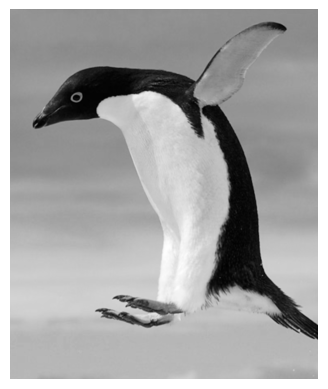

In [42]:
plt.axis('off')
BW = I[200:2000, 1500:3000].mean(axis=2)
print(BW.shape)
plt.imshow(I[200:2000, 1500:3000].mean(axis=2), 'Greys_r')

In [43]:
def discrete2DConvolution(Image, filter, padding):
  paddedImage= np.pad(Image, padding, 'constant')
  fltr = np.rot90(filter,2)
  conv=np.empty(Image.shape)
  #Striding and Multiplying
  for i in range(paddedImage.shape[0]-fltr.shape[0]):
    for j in range(paddedImage.shape[1]- fltr.shape[1]):
      conv[i,j] =np.sum((paddedImage[i:i+fltr.shape[0], j:j+fltr.shape[1]])*fltr)

  return conv

In [44]:
flterXX=np.array([[0,1,0],[0,1,0],[0,1,0]])
flterNeg=np.array([[-10,1,1],[-1,-1,-1],[-1,1,-1]])

flterREdge =np.array([[-10,0,10],[-10,0,10],[-10,0,10]])
flterLEdge =np.array([[10,0,-10],[10,0,-10],[10,0,-10]])

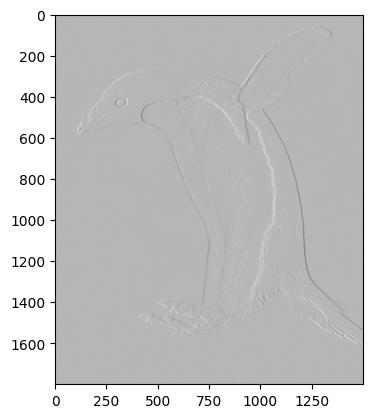

In [45]:
ImConv = discrete2DConvolution(BW, flterREdge, 1)
plt.imshow(ImConv, cmap='grey')

## Max Pooling

In [40]:
def MaxPool(Image, ksize, stride):
  n=0
  k=0

  vert = int(Image.shape[1]/stride)
  hoz = int(Image.shape[0]/stride)
  MxPool = np.empty((hoz,vert))

  for i in range(0, Image.shape[0]-stride, stride):
    n = 0
    for j in range(0,Image.shape[1]-stride, stride):
      MxPool[k,n] = np.max(Image[i:i+ksize,j:j+ksize])
      n+=1
    k+=1

  return MxPool

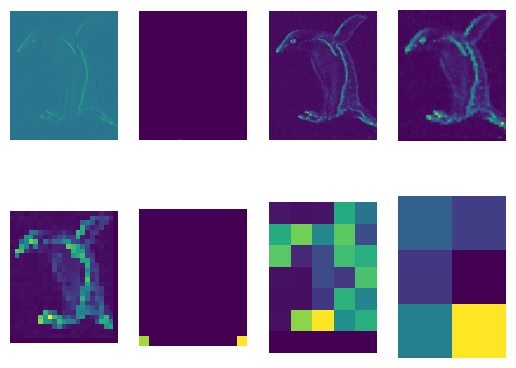

In [55]:
ImPool = MaxPool(ImConv, 2, 2)
for i in range(8):
    plt.subplot(2, 4, i+1)
    ImPool = MaxPool(ImPool, 2, 2)
    plt.imshow(ImPool)
    plt.axis('off')